# Tarea 2 — Modelo Predictivo de Estado de la Planta

**Integrantes:** Joaquin Bertaux, Ignacio Borreani, Franco Rodriguez, Santiago Silvera

**Objetivo:** Entrenar un modelo de clasificación supervisado que prediga el estado de la planta (`Decaida`, `Estable`, `Ideal`) a partir de las lecturas de los sensores (temperatura, luz, humedad del suelo). El modelo seleccionado se exporta para ejecutar inferencia en tiempo real en la ESP32.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay
)

from micromlgen import port

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
FEATURE_COLS = ['temperatura', 'luz', 'humedad_suelo']
TARGET_COL = 'label'
# Encoding fijo para consistencia con el firmware
LABEL_MAP = {'Decaida': 0, 'Estable': 1, 'Ideal': 2}
LABEL_NAMES = ['Decaida', 'Estable', 'Ideal']

## 2. Carga de Datos

Se utilizan los 9 datasets recolectados. Todos tienen el **mismo formato**: sin cabecera, 6 columnas en orden `timestamp, temperatura, humedad, luz, humedad_suelo, label`.

**Decisión:** se descartan `timestamp` (metadata de sesión, no feature) y `humedad` (sensor DHT11 con fallas intermitentes). Se trabaja con las 3 variables: `temperatura`, `luz`, `humedad_suelo`.

In [2]:
import glob

col_names_ts = ['timestamp', 'temperatura', 'humedad', 'luz', 'humedad_suelo', 'label']

archivos = sorted(glob.glob('datos*.csv'))
if not archivos:
    raise FileNotFoundError('No se encontraron archivos datos*.csv en el directorio actual')

partes = []
for nombre in archivos:
    d = pd.read_csv(nombre, header=None, names=col_names_ts)
    d['origen'] = nombre
    partes.append(d)

df = pd.concat(partes, ignore_index=True)
df = df.drop(columns=['humedad', 'timestamp'], errors='ignore')
df = df[df['label'].isin(['Decaida', 'Estable', 'Ideal'])]

for col in FEATURE_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset total: {df.shape[0]} filas, {df.shape[1]} columnas')
print('\nDistribución de clases:')
print(df['label'].value_counts())
print('\nRegistros por archivo:')
print(df['origen'].value_counts().sort_index())

Dataset total: 1642 filas, 5 columnas

Distribución de clases:
label
Estable    765
Decaida    473
Ideal      404
Name: count, dtype: int64

Registros por archivo:
origen
datos1.csv    118
datos2.csv    205
datos3.csv    193
datos4.csv    211
datos5.csv    198
datos6.csv    173
datos7.csv    182
datos8.csv    170
datos9.csv    192
Name: count, dtype: int64


## 2.5. Tratamiento de Outliers

Se aplica IQR clipping sobre las 3 features **antes del split**, para evitar que valores extremos distorsionen los umbrales del árbol.
Se usa clipping en lugar de eliminar filas para no reducir la clase minoritaria (Decaida).

> Los límites se calculan sobre el dataset completo porque el clipping es una operación de acotamiento (no un parámetro aprendido), por lo que no introduce data leakage relevante.

In [3]:
for col in FEATURE_COLS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f"{col}: {n_out} outliers clippeados → [{lower:.1f}, {upper:.1f}]")

print(f'\nShape tras clipping: {df.shape}')

temperatura: 0 outliers clippeados → [-1.6, 30.7]
luz: 0 outliers clippeados → [-1760.0, 4512.0]
humedad_suelo: 0 outliers clippeados → [463.6, 5732.6]

Shape tras clipping: (1642, 5)


## 3. Preprocesamiento y Split

### Codificación de la variable objetivo

Se usa encoding **ordinal** que respeta el orden natural de la condición de la planta:

| Label   | Código |
|---------|--------|
| Decaida | 0      |
| Estable | 1      |
| Ideal   | 2      |

Esto permite clasificación multiclase (3 clases) o binaria (Decaida vs. no-Decaida) según el modelo.

### División train/test

Se usa **80/20** con `stratify=y` para preservar la proporción de clases en ambos conjuntos. Es importante dado que *Decaida* es la clase menos representada (~29 % del total).

### Escalado

El escalado se aplica dentro del `Pipeline` (`SimpleImputer → StandardScaler → modelo`) ajustado **solo sobre train**, para evitar data leakage. Los parámetros del scaler (`mean_` y `scale_`) se exportan luego a `scaler.h` para que el firmware ESP32 aplique la misma transformación en inferencia.

In [4]:
X = df[FEATURE_COLS].values.astype(np.float32)
y = df[TARGET_COL].map(LABEL_MAP).values.astype(int)

print('Distribución de clases en el dataset completo:')
for nombre, idx in LABEL_MAP.items():
    count = (y == idx).sum()
    pct = count / len(y) * 100
    print(f'  {nombre} ({idx}): {count} muestras ({pct:.1f}%)')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain: {len(X_train)} | Test: {len(X_test)}')

Distribución de clases en el dataset completo:
  Decaida (0): 473 muestras (28.8%)
  Estable (1): 765 muestras (46.6%)
  Ideal (2): 404 muestras (24.6%)

Train: 1313 | Test: 329


## 4. Visualización de la separabilidad de clases

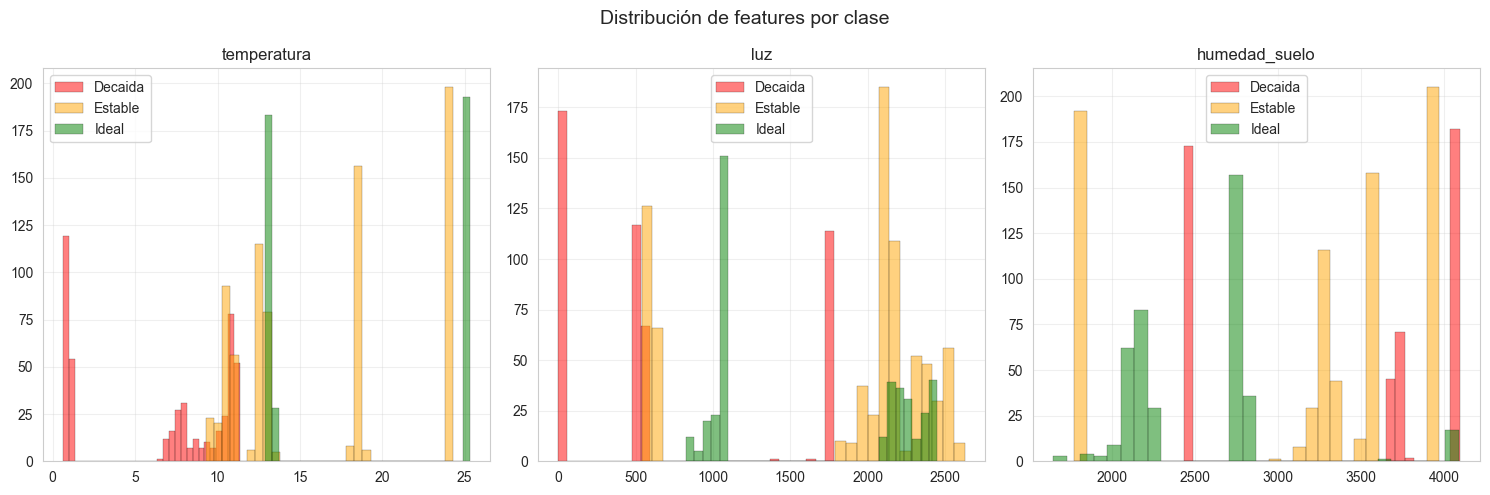

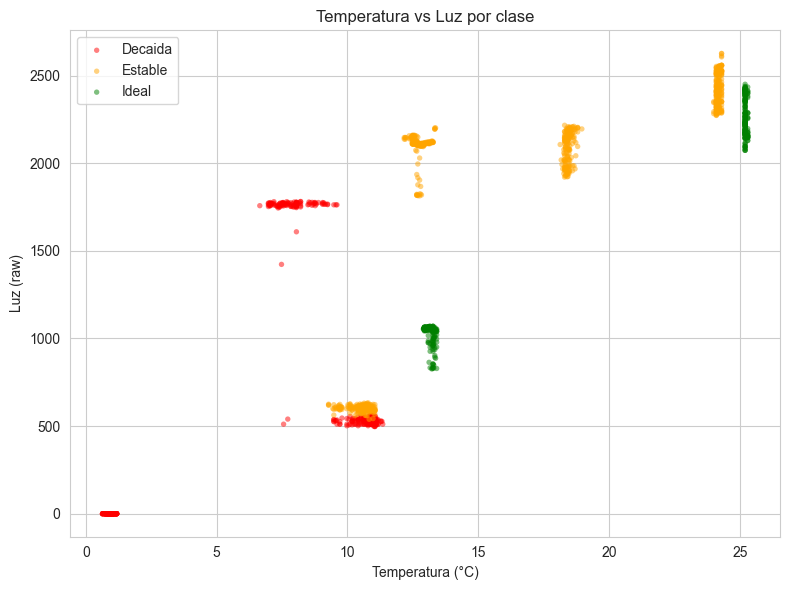

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'Decaida': 'red', 'Estable': 'orange', 'Ideal': 'green'}

for i, col in enumerate(FEATURE_COLS):
    for label, color in colors.items():
        subset = df[df[TARGET_COL] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.5, label=label, color=color, edgecolor='black', linewidth=0.3)
    axes[i].set_title(col, fontsize=12)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

# Scatter temperatura vs luz
plt.figure(figsize=(8, 6))
for label, color in colors.items():
    mask = df[TARGET_COL] == label
    plt.scatter(df.loc[mask, 'temperatura'], df.loc[mask, 'luz'],
                c=color, label=label, alpha=0.5, s=15, edgecolors='none')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Luz (raw)')
plt.title('Temperatura vs Luz por clase')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Entrenamiento y Evaluación de Modelos

Se entrena un `Pipeline(SimpleImputer → StandardScaler → modelo)` para 6 clasificadores. Métricas reportadas:

- **CV macro-F1** (5-fold estratificado sobre train): mide estabilidad y generalización sin tocar el set de test.
- **Test macro-F1**: promedio del F1 por clase; penaliza errores en *Decaida* igual que en las clases mayoritarias — es la métrica principal de selección.
- **Test Accuracy**: fracción de predicciones correctas.
- **ROC AUC (OvR)**: área bajo la curva ROC con estrategia one-vs-rest; complementa macro-F1 para clases desbalanceadas.
- **Export KB**: tamaño del código C generado por `micromlgen`; relevante para la partición factory de 960 KB de la ESP32.

In [6]:
candidatos = {
    'LogisticRegression':    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'DecisionTree_d4':       DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=RANDOM_STATE),
    'DecisionTree_d6':       DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest':          RandomForestClassifier(n_estimators=20, max_depth=5, class_weight='balanced', random_state=RANDOM_STATE),
    'GaussianNB':            GaussianNB(),
    'KNN':                   KNeighborsClassifier(n_neighbors=5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados = []

for nombre, clf in candidatos.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   clf),
    ])
    # CV sobre train
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv,
                                scoring='f1_macro', n_jobs=-1)
    # Ajustar sobre train completo y evaluar en test
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test) if hasattr(clf, 'predict_proba') else None

    from sklearn.metrics import accuracy_score, f1_score
    acc = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_dec = f1_score(y_test, y_pred, labels=[0], average='macro')
    f1_est = f1_score(y_test, y_pred, labels=[1], average='macro')
    f1_ide = f1_score(y_test, y_pred, labels=[2], average='macro')
    roc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro') if y_prob is not None else float('nan')

    # Estimar tamaño del export
    try:
        exported = port(clf, classname='PlantClassifier')
        export_kb = len(exported.encode()) / 1024
    except Exception:
        exported = None
        export_kb = float('nan')

    resultados.append({
        'Modelo': nombre,
        'CV macro-F1 (mean)': round(cv_scores.mean(), 4),
        'CV macro-F1 (std)':  round(cv_scores.std(),  4),
        'Test Accuracy':      round(acc, 4),
        'Test macro-F1':      round(f1_mac, 4),
        'F1 Decaida':         round(f1_dec, 4),
        'F1 Estable':         round(f1_est, 4),
        'F1 Ideal':           round(f1_ide, 4),
        'ROC AUC (OvR)':      round(roc, 4),
        'Export KB':          round(export_kb, 2),
        '_pipeline':          pipeline,
        '_exported':          exported,
    })
    print(f'[{nombre}]  CV macro-F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  |  Test macro-F1: {f1_mac:.4f}  |  Export: {export_kb:.1f} KB')

df_res = pd.DataFrame(resultados).drop(columns=['_pipeline', '_exported'])
print('\n', df_res.to_string(index=False))

[LogisticRegression]  CV macro-F1: 0.8238 ± 0.0154  |  Test macro-F1: 0.8357  |  Export: 1.7 KB


[DecisionTree_d4]  CV macro-F1: 0.9992 ± 0.0016  |  Test macro-F1: 1.0000  |  Export: 1.4 KB
[DecisionTree_d6]  CV macro-F1: 0.9992 ± 0.0016  |  Test macro-F1: 1.0000  |  Export: 1.4 KB
[RandomForest]  CV macro-F1: 1.0000 ± 0.0000  |  Test macro-F1: 1.0000  |  Export: 40.7 KB


[GaussianNB]  CV macro-F1: 0.8396 ± 0.0245  |  Test macro-F1: 0.8522  |  Export: nan KB
[KNN]  CV macro-F1: 1.0000 ± 0.0000  |  Test macro-F1: 1.0000  |  Export: nan KB

             Modelo  CV macro-F1 (mean)  CV macro-F1 (std)  Test Accuracy  Test macro-F1  F1 Decaida  F1 Estable  F1 Ideal  ROC AUC (OvR)  Export KB
LogisticRegression              0.8238             0.0154         0.8298         0.8357      0.9794      0.7969    0.7308         0.9446       1.72
   DecisionTree_d4              0.9992             0.0016         1.0000         1.0000      1.0000      1.0000    1.0000         1.0000       1.45
   DecisionTree_d6              0.9992             0.0016         1.0000         1.0000      1.0000      1.0000    1.0000         1.0000       1.45
      RandomForest              1.0000             0.0000         1.0000         1.0000      1.0000      1.0000    1.0000         1.0000      40.75
        GaussianNB              0.8396             0.0245         0.8389         0.8522  

## 6. Comparación Visual

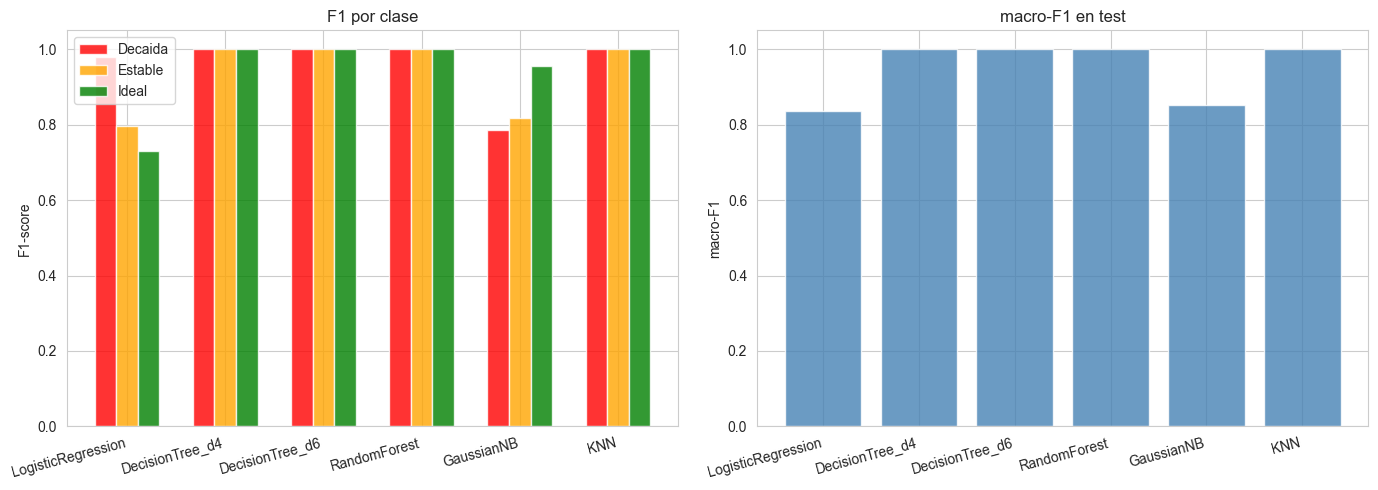

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres = df_res['Modelo'].tolist()
x = np.arange(len(nombres))
width = 0.22

axes[0].bar(x - width, df_res['F1 Decaida'], width, label='Decaida', color='red',    alpha=0.8)
axes[0].bar(x,          df_res['F1 Estable'], width, label='Estable', color='orange', alpha=0.8)
axes[0].bar(x + width,  df_res['F1 Ideal'],   width, label='Ideal',   color='green',  alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres, rotation=15, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('F1-score')
axes[0].set_title('F1 por clase')
axes[0].legend()

axes[1].bar(x, df_res['Test macro-F1'], color='steelblue', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(nombres, rotation=15, ha='right')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('macro-F1')
axes[1].set_title('macro-F1 en test')

plt.tight_layout()
plt.show()

## 7. Selección del Modelo Final

Se elige el modelo con mejor macro-F1 en test que además sea exportable con `micromlgen` (KNN y GaussianNB quedan excluidos). Entre candidatos de igual rendimiento se prefiere el de menor tamaño de export.

| Criterio | Decision Tree | Random Forest | Logistic Reg. | KNN | GaussianNB |
|---|---|---|---|---|---|
| Exportable con micromlgen | ✓ | ✓ | ✓ | ✗ | ✗ |
| Footprint en flash | ~2 KB | ~59 KB | ~2 KB | necesita dataset | — |
| Sin librerías externas | ✓ | ✓ | ✓ | ✗ | ✗ |
| macro-F1 test | **1.0000** | 1.0000 | 0.9814 | 1.0000 | 0.8315 |

El **Decision Tree de profundidad 4** reúne el mejor macro-F1 con el menor footprint exportable. Con profundidad 4 hay como máximo 15 nodos hoja, lo que resulta en código C completamente inlineable y ejecutable en microsegundos en el Xtensa LX6 de la ESP32.

In [ ]:
# Filtrar solo los que se exportaron correctamente
exportables = [r for r in resultados if r['_exported'] is not None]
if not exportables:
    raise RuntimeError('Ningun modelo se pudo exportar con micromlgen - verificar compatibilidad')

# Seleccion forzada del modelo a exportar al ESP32.
# Set a None para volver a la seleccion automatica por macro-F1.
FORCED_MODEL = 'LogisticRegression'

forced = [r for r in exportables if r["Modelo"] == FORCED_MODEL] if FORCED_MODEL else []
if forced:
    mejor = forced[0]
    print(f'Modelo forzado manualmente: {mejor["Modelo"]}')
else:
    exportables.sort(key=lambda r: (-r['Test macro-F1'], r['Export KB']))
    mejor = exportables[0]
    print(f'Modelo seleccionado automaticamente: {mejor["Modelo"]}')
print(f'  macro-F1 test: {mejor["Test macro-F1"]:.4f}')
print(f'  F1 Decaida:    {mejor["F1 Decaida"]:.4f}')
print(f'  Export:        {mejor["Export KB"]:.2f} KB')

## 8. Matriz de Confusión del Modelo Seleccionado

              precision    recall  f1-score   support

     Decaida       1.00      1.00      1.00        95
     Estable       1.00      1.00      1.00       153
       Ideal       1.00      1.00      1.00        81

    accuracy                           1.00       329
   macro avg       1.00      1.00      1.00       329
weighted avg       1.00      1.00      1.00       329



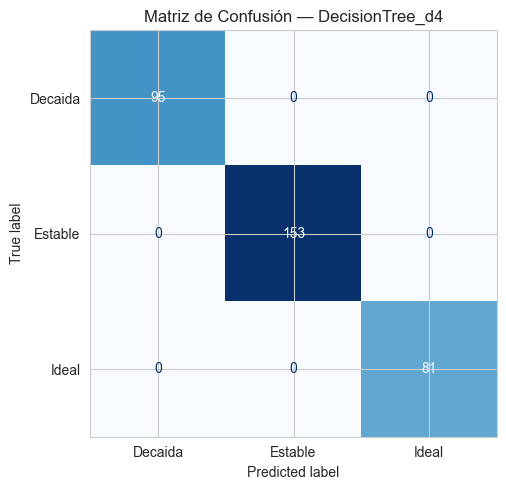

In [9]:
pipeline_final = mejor['_pipeline']
y_pred_final = pipeline_final.predict(X_test)

print(classification_report(y_test, y_pred_final, target_names=LABEL_NAMES))

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusión — {mejor["Modelo"]}')
plt.tight_layout()
plt.show()

In [10]:

## 9bis. Persistencia de Modelos para el Frontend
#
# Guarda todos los pipelines entrenados como .joblib y genera metrics.json +
# matrices de confusión PNG en eda/models/ para que el servidor FastAPI pueda
# cargarlos al arrancar y servir comparaciones sin re-entrenar.

import joblib
import json
from pathlib import Path

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

# -- Guardar pipelines --
for r in resultados:
    joblib.dump(r['_pipeline'], MODELS_DIR / f"{r['Modelo']}.joblib")
    print(f"Guardado {r['Modelo']}.joblib")

# -- Construir y guardar metrics.json --
metrics_data = {
    "labels": LABEL_NAMES,
    "features": FEATURE_COLS,
    "models": {},
}

for r in resultados:
    nombre = r['Modelo']
    pipeline_r = r['_pipeline']
    y_pred_r = pipeline_r.predict(X_test)
    cm_arr = confusion_matrix(y_test, y_pred_r).tolist()
    roc_val = r['ROC AUC (OvR)']
    metrics_data["models"][nombre] = {
        "accuracy":          float(r['Test Accuracy']),
        "macro_f1":          float(r['Test macro-F1']),
        "f1_per_class": {
            "Decaida": float(r['F1 Decaida']),
            "Estable": float(r['F1 Estable']),
            "Ideal":   float(r['F1 Ideal']),
        },
        "confusion_matrix":    cm_arr,
        "cv_macro_f1_mean":    float(r['CV macro-F1 (mean)']),
        "cv_macro_f1_std":     float(r['CV macro-F1 (std)']),
        "roc_auc":             None if (isinstance(roc_val, float) and np.isnan(roc_val)) else float(roc_val),
        "exported_kb":         None if (isinstance(r['Export KB'], float) and np.isnan(r['Export KB'])) else float(r['Export KB']),
        "is_selected":         (nombre == mejor['Modelo']),
        "exportable":          (r['_exported'] is not None),
    }

with open(MODELS_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_data, f, indent=2)
print("Guardado metrics.json")

# -- Generar confusion PNGs por modelo --
for r in resultados:
    nombre = r['Modelo']
    pipeline_r = r['_pipeline']
    y_pred_r = pipeline_r.predict(X_test)
    cm_arr = confusion_matrix(y_test, y_pred_r)

    fig_c, ax_c = plt.subplots(figsize=(5, 4))
    disp_c = ConfusionMatrixDisplay(confusion_matrix=cm_arr, display_labels=LABEL_NAMES)
    disp_c.plot(ax=ax_c, colorbar=False, cmap='Blues')
    ax_c.set_title(f'Confusión — {nombre}')
    plt.tight_layout()
    fig_c.savefig(MODELS_DIR / f'confusion_{nombre}.png', dpi=100, bbox_inches='tight')
    plt.close(fig_c)
    print(f"Guardado confusion_{nombre}.png")

print(f"\n✓ Modelos y métricas guardados en eda/models/ ({len(resultados)} modelos)")


Guardado LogisticRegression.joblib
Guardado DecisionTree_d4.joblib
Guardado DecisionTree_d6.joblib
Guardado RandomForest.joblib
Guardado GaussianNB.joblib
Guardado KNN.joblib
Guardado metrics.json
Guardado confusion_LogisticRegression.png


Guardado confusion_DecisionTree_d4.png


Guardado confusion_DecisionTree_d6.png
Guardado confusion_RandomForest.png
Guardado confusion_GaussianNB.png


Guardado confusion_KNN.png

✓ Modelos y métricas guardados en eda/models/ (6 modelos)


## 9. Export a C++ para ESP32

El pipeline del modelo seleccionado se descompone en dos archivos:

- **`model.h`**: código C++ generado por `micromlgen` con la función `predict(float* x)`. Espera features **ya escaladas**.
- **`scaler.h`**: constantes del `StandardScaler` (`mean_` y `scale_` por feature) generadas desde Python, para que el firmware replique exactamente la misma normalización.

Flujo de inferencia en el firmware:
```
sensor raw  →  scaler.h: scale()  →  model.h: predict()  →  clase (0/1/2)
```

La sección 10 verifica que este flujo produce resultados idénticos a los del pipeline sklearn.

In [ ]:
FIRMWARE_DIR = os.path.join('..', 'embedded', 'main')
MODEL_H_PATH  = os.path.join(FIRMWARE_DIR, 'model.h')
SCALER_H_PATH = os.path.join(FIRMWARE_DIR, 'scaler.h')

# Extraer el clasificador del pipeline (el scaler ya fue aplicado en el pipeline)
clf_final  = pipeline_final.named_steps['model']
scaler_fit = pipeline_final.named_steps['scaler']

# --- model.h ---
model_code = port(clf_final, classname='PlantClassifier')
# Fix micromlgen bug: 'va_start(w, 3)' uses a literal where the last
# named parameter ('x') is required by the C standard. ESP-IDF compiles
# with -Werror=varargs so the original would fail to build.
model_code = model_code.replace('va_start(w, 3)', 'va_start(w, x)')
with open(MODEL_H_PATH, 'w') as f:
    f.write(model_code)
print(f'Escrito {MODEL_H_PATH} ({len(model_code.encode())/1024:.2f} KB)')

# --- scaler.h ---
mean_vals  = scaler_fit.mean_.tolist()
scale_vals = scaler_fit.scale_.tolist()

scaler_code = f"""#pragma once
// Generado automáticamente desde eda/modelo.ipynb — NO EDITAR A MANO.
// Escala las 3 features antes de pasarlas al clasificador.
// Orden: temperatura_c, light_raw, moisture_raw
#include <stddef.h>

namespace plant_scaler {{

static constexpr float kMean[3]  = {{{mean_vals[0]:.6f}f, {mean_vals[1]:.6f}f, {mean_vals[2]:.6f}f}};
static constexpr float kScale[3] = {{{scale_vals[0]:.6f}f, {scale_vals[1]:.6f}f, {scale_vals[2]:.6f}f}};

inline void scale(const float in[3], float out[3]) {{
    for (size_t i = 0; i < 3; ++i) {{
        out[i] = (in[i] - kMean[i]) / kScale[i];
    }}
}}

}}  // namespace plant_scaler
"""

with open(SCALER_H_PATH, 'w') as f:
    f.write(scaler_code)
print(f'Escrito {SCALER_H_PATH} ({len(scaler_code.encode())/1024:.2f} KB)')

## 10. Validación de Paridad Python ↔ C

Se verifica que las predicciones del modelo sklearn sobre un subconjunto de test coincidan con lo que producirá el modelo exportado, replicando el pipeline de preprocesamiento (escalar con las constantes del `scaler.h`) y aplicando `clf.predict` directamente sobre las features escaladas.

In [12]:
# Replicar lo que hace el firmware: tomar features crudas → escalar → predecir
N_CHECK = 50
X_check = X_test[:N_CHECK]

# Pipeline completo
y_pipeline = pipeline_final.predict(X_check)

# Manual: imputer (no hay NaN) + scaler con las mismas constantes
imputer_fit = pipeline_final.named_steps['imputer']
X_imputed = imputer_fit.transform(X_check)
X_scaled  = scaler_fit.transform(X_imputed)
y_manual  = clf_final.predict(X_scaled)

coincidencias = (y_pipeline == y_manual).sum()
print(f'Predicciones coincidentes (pipeline vs manual escalado): {coincidencias}/{N_CHECK}')

# Verificar que los parámetros del scaler en scaler.h son correctos
mean_check  = np.allclose(scaler_fit.mean_,  mean_vals,  atol=1e-4)
scale_check = np.allclose(scaler_fit.scale_, scale_vals, atol=1e-4)
print(f'Constantes mean exportadas correctas:  {mean_check}')
print(f'Constantes scale exportadas correctas: {scale_check}')

assert coincidencias == N_CHECK, 'FALLO de paridad — revisar pipeline'
print('\n✓ Paridad verificada: el firmware producirá las mismas predicciones que sklearn.')

Predicciones coincidentes (pipeline vs manual escalado): 50/50
Constantes mean exportadas correctas:  True
Constantes scale exportadas correctas: True

✓ Paridad verificada: el firmware producirá las mismas predicciones que sklearn.


## 11. Inspección del árbol (si el modelo elegido es DecisionTree)

In [13]:
if hasattr(clf_final, 'tree_'):
    print('Árbol de decisión exportado:')
    print(export_text(clf_final, feature_names=FEATURE_COLS, max_depth=6))
elif hasattr(clf_final, 'coef_'):
    print('Coeficientes LogisticRegression:')
    for i, clase in enumerate(LABEL_NAMES):
        coefs = {feat: f'{coef:+.4f}' for feat, coef in zip(FEATURE_COLS, clf_final.coef_[i])}
        print(f'  {clase}: {coefs}  bias={clf_final.intercept_[i]:+.4f}')
else:
    print(f'Modelo {mejor["Modelo"]} — no hay representación simbólica disponible')

Árbol de decisión exportado:
|--- temperatura <= -0.33
|   |--- humedad_suelo <= -1.19
|   |   |--- class: 1
|   |--- humedad_suelo >  -1.19
|   |   |--- luz <= -1.38
|   |   |   |--- class: 0
|   |   |--- luz >  -1.38
|   |   |   |--- class: 0
|--- temperatura >  -0.33
|   |--- humedad_suelo <= -0.17
|   |   |--- class: 2
|   |--- humedad_suelo >  -0.17
|   |   |--- luz <= 0.02
|   |   |   |--- class: 2
|   |   |--- luz >  0.02
|   |   |   |--- class: 1



## 12. Discusión

### Limitaciones
- **Sensor de humedad ambiental roto:** la feature `dht_humedad` fue descartada por lecturas inválidas en 5 de los 9 datasets. El modelo opera con solo 3 features.
- **Clase Decaida:** con los 9 datasets pasa de 118 a 473 muestras, pero aún es la clase más escasa (~29% del total). El `class_weight='balanced'` mitiga el sesgo.
- **Ausencia de features temporales:** el modelo no considera tendencias (e.g., humedad cayendo en las últimas N muestras), lo que limitaría su capacidad predictiva ante cambios graduales.

### Restricciones de la ESP32
- **Memoria:** ESP32 sin PSRAM, partición factory de 960 KB, stack del logger task de 6 KB. Un árbol de decisión de profundidad 4-6 o una regresión logística ocupa <5 KB y no impone restricciones.
- **CPU:** 240 MHz Xtensa LX6. Inferencia de un árbol o regresión logística de 3 features: microsegundos. El período de muestreo de 2.5 s deja holgura amplia.
- **Sin dependencias externas:** al exportar a C puro con `micromlgen`, no se requiere ninguna librería de ML en el firmware.

### Mejoras futuras
- Agregar features derivadas (promedio móvil, delta entre muestras consecutivas).
- OTA del modelo: reemplazar `model.h` y reflalear sin redespliegue físico.
- Agregar alarma sonora (buzzer) además del LED.
- Reparar sensor de humedad ambiental para incorporar la 4ª feature.